# Load and vehicle capacities

In this tutorial we dive deeper into the modelling of client deliveries, pickups, and vehicle capacities.
We jointly refer to pickup and delivery amounts as *load*.
When a client requests a particular delivery amount, that amount needs to travel from the depot to the client.
Similarly, a client pickup amount needs to travel from the client back to the depot - a case of reverse logistics.
Clients may simultaneously demand pickups and deliveries.
The total amount of client pickups and deliveries present in the vehicle must not at any point exceed the vehicle capacity.
Let's look at a few simple examples.

In [1]:
import pyvrp
import pyvrp.plotting
import pyvrp.stop

## Deliveries

Let's first look at a small delivery example with just two clients, modelling a classic capacitated vehicle routing problem.
The delivery demand is loaded into the vehicle at the depot, and delivered to each customer.

In [2]:
COORDS = [(0, 0), (0, 1), (2.5, 0)]
DELIVERIES = [4, 5]

In [3]:
m = pyvrp.Model()
m.add_vehicle_type(2, capacity=10)
m.add_depot(location=m.add_location(x=COORDS[0][0], y=COORDS[0][1]))

m.add_client(
    location=m.add_location(x=COORDS[1][0], y=COORDS[1][1]),
    delivery=DELIVERIES[0],
)

m.add_client(
    location=m.add_location(x=COORDS[2][0], y=COORDS[2][1]),
    delivery=DELIVERIES[1],
)

for idx_frm, frm in enumerate(m.locations):
    for idx_to, to in enumerate(m.locations):
        if idx_frm != idx_to:
            m.add_edge(frm, to, distance=1)  # unit distances

res = m.solve(stop=pyvrp.stop.MaxRuntime(1))  # one second of runtime

PyVRP v0.14.0


Solving an instance with:


    1 depot


    2 clients


    0 shipments


...

   objective: 3


    distance: 3


    duration: 0


# iterations: 75257


    run-time: 1.00 seconds


A single vehicle is assigned since the total delivery demand sums to just 9, below the vehicle's capacity of 10.

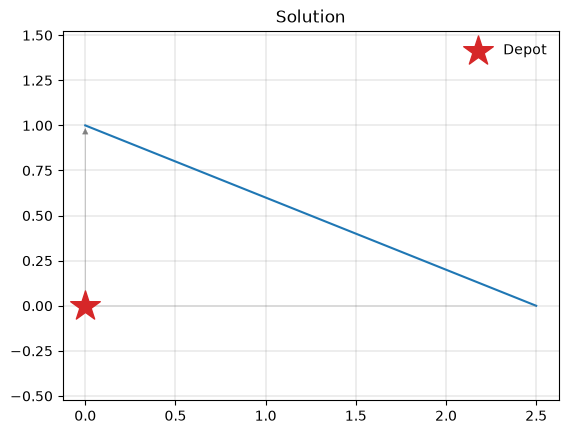

In [4]:
pyvrp.plotting.plot_solution(res.best, m.data())

## Mixed pickups and deliveries

Beyond simple deliveries, clients can also request pickups.
A pickup is loaded at the customer, and returned to the depot.

In [5]:
PICKUPS = [6, 0]

In [6]:
m = pyvrp.Model()
m.add_vehicle_type(2, capacity=10)

m.add_depot(location=m.add_location(x=COORDS[0][0], y=COORDS[0][1]))

for idx in [1, 2]:
    m.add_client(
        location=m.add_location(x=COORDS[idx][0], y=COORDS[idx][1]),
        delivery=DELIVERIES[idx - 1],
        pickup=PICKUPS[idx - 1],
    )

for frm in m.locations:
    for to in m.locations:
        if frm != to:
            m.add_edge(frm, to, distance=1)  # unit distances

res = m.solve(stop=pyvrp.stop.MaxRuntime(1))  # one second of runtime

PyVRP v0.14.0


Solving an instance with:


    1 depot


    2 clients


    0 shipments


...

   objective: 3


    distance: 3


    duration: 0


# iterations: 78437


    run-time: 1.00 seconds


A single vehicle is still able to serve all pickup and delivery demand, but now the vehicle's capacity is utilised far better throughout the route:

In [7]:
route = res.best.routes()[0]

for idx, activity in enumerate(route):
    if idx == 0:
        print(f"- Loading {route.delivery()} at depot.")
    elif idx == len(route) - 1:
        print(f"- Unloading {route.pickup()} at depot.")
    else:
        client = m.clients[activity.idx]
        delivery = client.delivery
        pickup = client.pickup
        print(f"- Delivering {delivery} at client, picking up {pickup}.")

- Loading [9] at depot.
- Delivering [5] at client, picking up [0].
- Delivering [4] at client, picking up [6].
- Unloading [6] at depot.


## Multiple load dimensions

We have so far looked at only a single load dimension.
PyVRP supports arbitrarily many load dimensions, which can be helpful to express constraints on additional physical attributes like weight, volume, height and width.
However, load dimension can also be used to model compatibility constraints, like specific skills: if the vehicle's capacity is zero in a particular dimension, it cannot service clients requiring that particular skill.

The following example illustrates this use of load dimensions.
The first vehicle does not have a particular skill in the second load dimension.
The second vehicle does, but is more expensive to operate, with a fixed cost of 10 units.
The first client requires the vehicle's skill, the second does not.

In the solution, the first client must be assigned to the second vehicle, despite its higher operating cost.

In [8]:
m = pyvrp.Model()

m.add_depot(location=m.add_location(x=COORDS[0][0], y=COORDS[0][1]))

m.add_vehicle_type(1, capacity=[10, 0])
m.add_vehicle_type(1, capacity=[5, 1], fixed_cost=10)

m.add_client(
    location=m.add_location(x=COORDS[1][0], y=COORDS[1][1]),
    delivery=[5, 1],
)

m.add_client(
    location=m.add_location(x=COORDS[2][0], y=COORDS[2][1]),
    delivery=[5, 0],
)

for frm in m.locations:
    for to in m.locations:
        if frm != to:
            m.add_edge(frm, to, distance=1)  # unit distances

res = m.solve(stop=pyvrp.stop.MaxRuntime(1))  # one second of runtime

PyVRP v0.14.0


Solving an instance with:


    1 depot


    2 clients


    0 shipments


...

   objective: 14


    distance: 4


    duration: 0


# iterations: 71723


    run-time: 1.00 seconds


We see that indeed the first client is assigned to the second vehicle:

In [9]:
print(res.best)

Route #1: C1
Route #2: C0



## Conclusion

In this notebook we explored how PyVRP's load modelling works.
You now understand how to use pickups, deliveries, and vehicle capacities to model a wide range of constraints.